# 02 — Validación y exploración de los escenarios de Loss Incurred

## Objetivo

Esta etapa verifica que las bases generadas durante la fase de diseño y
simulación cumplen las propiedades estructurales y actuariales definidas
para el experimento.

Se analizarán los tres escenarios:

- **creciente**, con `dev_M = 60`;
- **decreciente**, con `dev_M = 48`;
- **mixto**, con `dev_M = 48`.

La validación se divide en cuatro componentes principales:

1. comprobar la estructura y consistencia de las bases;
2. verificar los periodos de ocurrencia y desarrollo;
3. construir y validar los triángulos acumulados e incrementales;
4. estudiar los factores edad-a-edad y comprobar que el patrón observado
   corresponde al escenario diseñado.

Las funciones reutilizables se mantienen en `src`, mientras que este
notebook se concentra en mostrar los resultados, diagnosticar posibles
problemas e interpretar actuarialmente el comportamiento de las bases.

## 1. Estrategia de validación

La simulación produce una base en formato largo donde cada observación
corresponde a una combinación de:

$$
(\text{escenario},
 \text{periodo de ocurrencia},
 \text{edad de desarrollo})
$$

Por construcción, para una observación con periodo de ocurrencia $i$
y edad de desarrollo $j$, el periodo calendario debe satisfacer:

$$
c = i + j.
$$

Además, cada periodo de ocurrencia debe observarse desde la edad 0 hasta
el horizonte de madurez `dev_M` correspondiente al escenario.

En la fase anterior se estableció también la condición:

$$
LI_{i,M} = U_i,
$$

donde:

- $LI_{i,M}$ es el Loss Incurred del periodo de ocurrencia $i$
  en su edad de madurez;
- $U_i$ es su pérdida Ultimate simulada;
- $M$ corresponde a `dev_M`.

Estas propiedades se validan mediante las funciones definidas en
`src.validation`. El notebook no replica dichas reglas: únicamente
ejecuta las funciones y analiza sus resultados.

### Imports

In [53]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from IPython.display import display

# Permite importar src/ cuando el notebook se ejecuta desde notebooks/
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.validation import validate_all_scenarios

### Recuperar las simulaciones

In [54]:
from src.simulation import simulate_all_scenarios, SimulationConfig

config = SimulationConfig()

simulations = simulate_all_scenarios(config)

simulations.keys()

dict_keys(['creciente', 'decreciente', 'mixto'])

### Configuración esperada de esta validación

In [55]:
EXPECTED_DEV_M = {
    "creciente": 60,
    "decreciente": 48,
    "mixto": 48,
}

ACCIDENT_START = "2015-01"
ACCIDENT_END = "2025-12"

## 2. Inspección inicial de las bases

Antes de aplicar pruebas formales se revisan las dimensiones y primeras
observaciones de cada escenario.

Esta inspección no sustituye las validaciones automáticas. Su objetivo es
permitir observar directamente la estructura de la información que
posteriormente será transformada en triángulos.

In [56]:
for scenario, df in simulations.items():
    print("=" * 70)
    print(f"ESCENARIO: {scenario.upper()}")
    print("=" * 70)

    print(f"Filas:    {df.shape[0]:,}")
    print(f"Columnas: {df.shape[1]:,}")
    print()

    display(df.head())

ESCENARIO: CRECIENTE
Filas:    8,052
Columnas: 15



,scenario,accident_period,dev_month,calendar_period,dev_M,month_index,trend_factor,seasonality_factor,occurrence_noise,expected_ultimate,ultimate_loss,development_factor,development_noise,expected_loss_incurred,loss_incurred
0,creciente,2015-01,0,2015-01,60,0,1.0,1.0,1.021403,1000000.0,1.021403e+06,0.550000,1.009459,561771.758988,567085.683055
1,creciente,2015-01,1,2015-02,60,0,1.0,1.0,1.021403,1000000.0,1.021403e+06,0.573097,0.996560,585362.776391,583349.180911
2,creciente,2015-01,2,2015-03,60,0,1.0,1.0,1.021403,1000000.0,1.021403e+06,0.595067,0.978069,607803.246298,594473.789657
3,creciente,2015-01,3,2015-04,60,0,1.0,1.0,1.021403,1000000.0,1.021403e+06,0.615966,0.984771,629149.281573,619567.946055
4,creciente,2015-01,4,2015-05,60,0,1.0,1.0,1.021403,1000000.0,1.021403e+06,0.635845,1.004601,649454.258423,652442.240852


ESCENARIO: DECRECIENTE
Filas:    6,468
Columnas: 15



,scenario,accident_period,dev_month,calendar_period,dev_M,month_index,trend_factor,seasonality_factor,occurrence_noise,expected_ultimate,ultimate_loss,development_factor,development_noise,expected_loss_incurred,loss_incurred
0,decreciente,2015-01,0,2015-01,48,0,1.0,1.0,1.016473,1000000.0,1.016473e+06,1.250000,0.997443,1.270591e+06,1.267341e+06
1,decreciente,2015-01,1,2015-02,48,0,1.0,1.0,1.016473,1000000.0,1.016473e+06,1.234060,1.001435,1.254388e+06,1.256188e+06
2,decreciente,2015-01,2,2015-03,48,0,1.0,1.0,1.016473,1000000.0,1.016473e+06,1.219085,1.011078,1.239167e+06,1.252894e+06
3,decreciente,2015-01,3,2015-04,48,0,1.0,1.0,1.016473,1000000.0,1.016473e+06,1.205018,0.978803,1.224867e+06,1.198904e+06
4,decreciente,2015-01,4,2015-05,48,0,1.0,1.0,1.016473,1000000.0,1.016473e+06,1.191803,1.008448,1.211435e+06,1.221669e+06


ESCENARIO: MIXTO
Filas:    6,468
Columnas: 15



,scenario,accident_period,dev_month,calendar_period,dev_M,month_index,trend_factor,seasonality_factor,occurrence_noise,expected_ultimate,ultimate_loss,development_factor,development_noise,expected_loss_incurred,loss_incurred
0,mixto,2015-01,0,2015-01,48,0,1.0,1.0,1.119047,1000000.0,1.119047e+06,0.650000,0.986070,727380.250608,717247.496370
1,mixto,2015-01,1,2015-02,48,0,1.0,1.0,1.119047,1000000.0,1.119047e+06,0.654458,1.000508,732369.141215,732741.242081
2,mixto,2015-01,2,2015-03,48,0,1.0,1.0,1.119047,1000000.0,1.119047e+06,0.667147,1.053205,746568.291407,786289.419653
3,mixto,2015-01,3,2015-04,48,0,1.0,1.0,1.119047,1000000.0,1.119047e+06,0.687037,0.986196,768826.418733,758213.351787
4,mixto,2015-01,4,2015-05,48,0,1.0,1.0,1.119047,1000000.0,1.119047e+06,0.713100,0.997364,797992.240748,795888.496588


### Resumen estructural

In [57]:
structure_summary = pd.DataFrame(
    [
        {
            "scenario": scenario,
            "rows": len(df),
            "accident_periods": df["accident_period"].nunique(),
            "dev_min": df["dev_month"].min(),
            "dev_max": df["dev_month"].max(),
            "calendar_start": df["calendar_period"].min(),
            "calendar_end": df["calendar_period"].max(),
        }
        for scenario, df in simulations.items()
    ]
)

structure_summary

,scenario,rows,accident_periods,dev_min,dev_max,calendar_start,calendar_end
0,creciente,8052,132,0,60,2015-01,2030-12
1,decreciente,6468,132,0,48,2015-01,2029-12
2,mixto,6468,132,0,48,2015-01,2029-12


### Interpretación del resumen estructural

Los tres escenarios contienen los 132 periodos mensuales de ocurrencia
comprendidos entre enero de 2015 y diciembre de 2025.

El número de observaciones difiere debido al horizonte de desarrollo de
cada escenario:

- creciente: $132 \times 61 = 8{,}052$ observaciones;
- decreciente: $132 \times 49 = 6{,}468$;
- mixto: $132 \times 49 = 6{,}468$.

Aunque el último periodo de ocurrencia es diciembre de 2025, la base
completa contiene desarrollos calendario posteriores. Por ejemplo, el
escenario creciente alcanza diciembre de 2030 debido a su horizonte de
60 meses.

Estos periodos futuros forman parte de la verdad simulada y no implican
que posteriormente puedan utilizarse en una valuación histórica.

## 3. Validación estructural

Las siguientes pruebas verifican automáticamente las condiciones básicas
que deben cumplir las bases antes de construir los triángulos.

Se comprueba:

- presencia de las columnas requeridas;
- ausencia de valores faltantes;
- unicidad de la clave
  `(scenario, accident_period, dev_month)`;
- consistencia del escenario;
- consistencia de `dev_M`;
- edades de desarrollo completas desde 0 hasta `dev_M`;
- rango mensual de periodos de ocurrencia;
- disponibilidad de todas las edades para cada periodo de ocurrencia;
- identidad entre periodo calendario, ocurrencia y desarrollo;
- positividad de importes y factores de simulación;
- igualdad entre Loss Incurred y Ultimate en la edad de madurez.

La implementación de estas pruebas se encuentra en
`src.validation.validate_all_scenarios`.

In [58]:
validation_results = validate_all_scenarios(
    simulations=simulations,
    expected_dev_M=EXPECTED_DEV_M,
    expected_start=ACCIDENT_START,
    expected_end=ACCIDENT_END,
)

validation_results

,scenario,check,passed,detail
0,creciente,required_columns,True,Todas las columnas requeridas están presentes.
1,creciente,non_empty,True,"Número de observaciones: 8,052"
2,creciente,scenario_consistency,True,Escenarios observados: ['creciente']
3,creciente,no_missing_values,True,Valores faltantes encontrados: 0
4,creciente,unique_key,True,Claves duplicadas: 0
5,creciente,dev_M_consistency,True,dev_M observado: [60]; dev_M esperado: 60
6,creciente,development_range,True,Rango observado: 0–60; rango esperado: 0–60
7,creciente,accident_period_range,True,Periodo observado: 2015-01–2025-12; 132 meses.
8,creciente,complete_development_by_accident_period,True,Edades esperadas por periodo: 61; mínimo obser...
9,creciente,calendar_period_consistency,True,calendar_period coincide con accident_period +...


### Mostrar las fallas

In [59]:
failed_checks = validation_results.loc[
    ~validation_results["passed"]
]

if failed_checks.empty:
    print("✓ Todas las validaciones estructurales fueron superadas.")
else:
    print("✗ Se encontraron validaciones fallidas:")
    display(failed_checks)

✓ Todas las validaciones estructurales fueron superadas.


### Resumen por escenario

In [60]:
validation_summary = (
    validation_results
    .groupby("scenario")
    .agg(
        checks=("check", "count"),
        passed=("passed", "sum"),
    )
)

validation_summary["failed"] = (
    validation_summary["checks"]
    - validation_summary["passed"]
)

validation_summary["all_passed"] = (
    validation_summary["failed"] == 0
)

validation_summary

,checks,passed,failed,all_passed
scenario,,,,
creciente,13,13,0,True
decreciente,13,13,0,True
mixto,13,13,0,True


### Conclusión de la validación estructural

Los tres escenarios superan las 13 comprobaciones definidas.

Por tanto, antes de analizar el comportamiento actuarial puede afirmarse
que las bases presentan:

- claves únicas;
- periodos de ocurrencia completos;
- edades de desarrollo consistentes con `dev_M`;
- importes y factores de simulación válidos;
- coherencia entre ocurrencia, desarrollo y periodo calendario;
- convergencia exacta del Loss Incurred al Ultimate en la madurez.

Con estas condiciones verificadas, las diferencias observadas entre
escenarios pueden atribuirse al mecanismo de desarrollo diseñado y no a
problemas estructurales de las bases.

## 4. Factores edad-a-edad

Una vez validada la estructura de las bases, se analiza directamente
el comportamiento del Loss Incurred a través del desarrollo.

Para un periodo de ocurrencia $i$ y una edad de desarrollo $j$,
el factor individual edad-a-edad se define como:

$$
f_{i,j}
=
\frac{LI_{i,j+1}}
     {LI_{i,j}}.
$$

Este factor mide cuánto cambia el Loss Incurred entre dos edades
consecutivas.

Por tanto:

- $f_{i,j} > 1$: el Loss Incurred aumenta;
- $f_{i,j} < 1$: el Loss Incurred disminuye;
- $f_{i,j} = 1$: no existe cambio entre ambas edades.

Debido al componente aleatorio incorporado durante la simulación,
no se espera necesariamente que todas las observaciones individuales
sigan exactamente la dirección teórica del escenario.

Por esta razón también se calcula un factor agregado por edad mediante
ponderación por volumen:

$$
f_j
=
\frac{\sum_i LI_{i,j+1}}
     {\sum_i LI_{i,j}}.
$$

Esta formulación coincide con el estimador volumen-ponderado utilizado
habitualmente en métodos de desarrollo como Chain-Ladder y permite
identificar con mayor claridad el patrón general del escenario.

### Imports

In [61]:
from src.analysis import (
    calculate_individual_age_to_age_factors,
    calculate_volume_weighted_factors,
)

from src.validation import (
    validate_all_scenarios,
    validate_development_patterns,
)

### Calcular factores para los tres escenarios

In [62]:
individual_factors = pd.concat(
    [
        calculate_individual_age_to_age_factors(df)
        for df in simulations.values()
    ],
    ignore_index=True,
)

individual_factors.head()

,scenario,accident_period,dev_month,loss_incurred_current,loss_incurred_next,age_to_age_factor
0,creciente,2015-01,0,567085.683055,583349.180911,1.028679
1,creciente,2015-01,1,583349.180911,594473.789657,1.019070
2,creciente,2015-01,2,594473.789657,619567.946055,1.042212
3,creciente,2015-01,3,619567.946055,652442.240852,1.053060
4,creciente,2015-01,4,652442.240852,677153.533699,1.037875


### Agregación de los factores por edad

Los factores individuales permiten estudiar cada trayectoria de
ocurrencia por separado. Sin embargo, para identificar el patrón global
del escenario se agregan las observaciones de una misma edad de
desarrollo mediante ponderación por volumen:

$$
f_j =
\frac{\sum_i LI_{i,j+1}}
     {\sum_i LI_{i,j}}.
$$

Además del factor volumen-ponderado se conservan la media y la mediana de
los factores individuales como medidas descriptivas complementarias.

In [63]:
development_factors = (
    calculate_volume_weighted_factors(
        individual_factors
    )
)

development_factors.head()

,scenario,dev_month,current_sum,next_sum,n_observations,median_individual_factor,mean_individual_factor,volume_weighted_factor
0,creciente,0,9.007224e+07,9.391916e+07,132,1.042565,1.043012,1.042709
1,creciente,1,9.391916e+07,9.731591e+07,132,1.034432,1.036760,1.036167
2,creciente,2,9.731591e+07,1.006077e+08,132,1.033904,1.033982,1.033826
3,creciente,3,1.006077e+08,1.038611e+08,132,1.033702,1.032278,1.032337
4,creciente,4,1.038611e+08,1.070952e+08,132,1.033956,1.031845,1.031139


### Validación rápida de las edades

In [64]:
factor_ranges = (
    development_factors
    .groupby("scenario")
    .agg(
        dev_min=("dev_month", "min"),
        dev_max=("dev_month", "max"),
        n_factors=("dev_month", "size"),
    )
)

factor_ranges

,dev_min,dev_max,n_factors
scenario,,,
creciente,0,59,60
decreciente,0,47,48
mixto,0,47,48


### Tabla resumen

In [65]:
factor_summary = (
    development_factors
    .groupby("scenario")
    .agg(
        n_factors=("volume_weighted_factor", "size"),
        min_factor=("volume_weighted_factor", "min"),
        mean_factor=("volume_weighted_factor", "mean"),
        max_factor=("volume_weighted_factor", "max"),
        factors_above_1=(
            "volume_weighted_factor",
            lambda x: (x > 1).sum(),
        ),
        factors_below_1=(
            "volume_weighted_factor",
            lambda x: (x < 1).sum(),
        ),
    )
)

factor_summary["pct_above_1"] = (
    factor_summary["factors_above_1"]
    / factor_summary["n_factors"]
)

factor_summary["pct_below_1"] = (
    factor_summary["factors_below_1"]
    / factor_summary["n_factors"]
)

factor_summary

,n_factors,min_factor,mean_factor,max_factor,factors_above_1,factors_below_1,pct_above_1,pct_below_1
scenario,,,,,,,,
creciente,60,0.998564,1.010050,1.042709,57,3,0.950000,0.050000
decreciente,48,0.985424,0.995416,1.002093,4,44,0.083333,0.916667
mixto,48,0.989896,1.009204,1.052245,19,29,0.395833,0.604167


### Gráfico factores de desarrollo

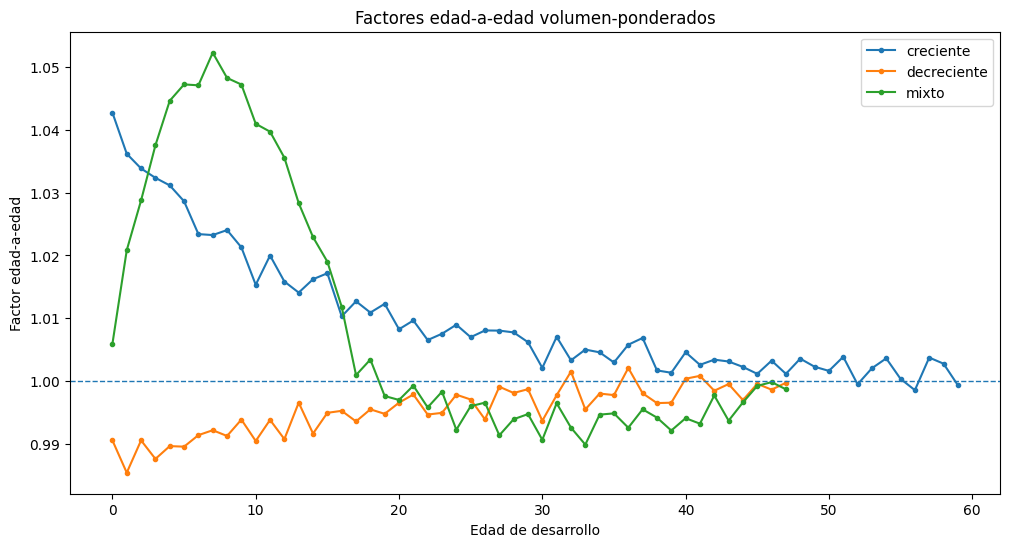

In [66]:
fig, ax = plt.subplots(figsize=(12, 6))

for scenario, group in development_factors.groupby("scenario"):
    ax.plot(
        group["dev_month"],
        group["volume_weighted_factor"],
        marker="o",
        markersize=3,
        label=scenario,
    )

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel("Edad de desarrollo")
ax.set_ylabel("Factor edad-a-edad")
ax.set_title(
    "Factores edad-a-edad volumen-ponderados"
)
ax.legend()

plt.show()

In [67]:
pattern_validation = (
    validate_development_patterns(
        development_factors,
        min_share=0.80,
    )
)

pattern_validation

,scenario,check,observed_share,required_share,passed
0,creciente,predominantly_above_1,0.950000,0.8,True
1,decreciente,predominantly_below_1,0.916667,0.8,True
2,mixto,early_development_above_1,1.000000,0.8,True
3,mixto,late_development_below_1,1.000000,0.8,True


In [68]:
if pattern_validation["passed"].all():
    print(
        "✓ Los tres escenarios presentan "
        "el patrón de desarrollo esperado."
    )
else:
    print(
        "✗ Alguno de los escenarios no cumple "
        "el patrón de desarrollo esperado."
    )

    display(
        pattern_validation.loc[
            ~pattern_validation["passed"]
        ]
    )

✓ Los tres escenarios presentan el patrón de desarrollo esperado.


### Interpretación de los factores edad-a-edad

Los resultados confirman que el componente aleatorio incorporado en la
simulación conserva el comportamiento general definido para cada escenario
sin producir trayectorias artificialmente deterministas.

En el escenario **creciente**, 57 de los 60 factores agregados
(95.0 %) son superiores a 1. Los factores presentan sus mayores valores
en edades tempranas y convergen progresivamente hacia 1 conforme se
alcanza la madurez.

En el escenario **decreciente**, 44 de los 48 factores
(91.7 %) son inferiores a 1. Esto refleja una reducción progresiva del
Loss Incurred, también con movimientos cada vez menores conforme aumenta
la edad de desarrollo.

El escenario **mixto** muestra un comportamiento diferente. Los factores
son superiores a 1 durante las edades tempranas, alcanzan un máximo en
la primera parte del desarrollo y posteriormente descienden por debajo
de 1. Esta combinación reproduce el patrón diseñado de incremento inicial
seguido por ajustes decrecientes.

En los tres escenarios los factores tienden hacia 1 en edades avanzadas.
Este comportamiento es consistente con la definición de `dev_M`, donde el
Loss Incurred converge finalmente al Ultimate simulado.

> **Nota metodológica.**
>
> Los factores calculados en esta sección utilizan las trayectorias
> completas simuladas porque su objetivo es validar el mecanismo generador
> de cada escenario.
>
> No deben interpretarse como factores que habrían estado disponibles en
> una valuación histórica. Cuando se trabaje con información observable o
> con backtesting, los factores deberán estimarse únicamente con las
> celdas disponibles hasta cada fecha de corte.

## 5. Construcción de triángulos

La base simulada contiene el desarrollo completo de cada periodo de
ocurrencia hasta su respectivo `dev_M`.

Sin embargo, esa información representa también desarrollos que, desde
la perspectiva de una fecha histórica de valuación, todavía pertenecerían
al futuro.

Por esta razón, antes de construir un triángulo actuarial se aplica un
corte calendario:

$$
calendar\_period \leq valuation\_period.
$$

Para este análisis se utiliza como fecha de valuación más reciente:

$$
\text{2025-12}.
$$

Así, una ocurrencia de diciembre de 2025 únicamente contiene la edad de
desarrollo 0, mientras que periodos de ocurrencia suficientemente antiguos
pueden encontrarse completamente desarrollados.

Esta distinción permite separar:

- la **base completa simulada**, utilizada como verdad conocida dentro
  del experimento;
- la **información observable a una valuación**, utilizada para construir
  los triángulos.

El triángulo acumulado se representa como:

$$
C_{i,j}=LI_{i,j},
$$

donde $i$ identifica el periodo de ocurrencia y $j$ la edad de
desarrollo.

### Imports

In [69]:
from src.triangles import (
    build_triangle_pair,
    incremental_to_cumulative,
)

VALUATION_PERIOD = "2025-12"

### Construir los tres pares de triángulos

In [70]:
triangles = {}

for scenario, df in simulations.items():

    cumulative, incremental = build_triangle_pair(
        df=df,
        valuation_period=VALUATION_PERIOD,
    )

    triangles[scenario] = {
        "cumulative": cumulative,
        "incremental": incremental,
    }

### Inspección de dimensiones

#### Interpretación de la estructura triangular

Las 132 filas corresponden a los periodos mensuales de ocurrencia entre
2015-01 y 2025-12.

El número máximo de columnas depende de `dev_M`:

- 61 edades para el escenario creciente: $0,\ldots,60$;
- 49 para decreciente y mixto: $0,\ldots,48$.

Las celdas `NaN` no representan información faltante en la simulación.
Corresponden a desarrollos que todavía no son observables a la fecha de
valuación 2025-12.

Por ejemplo, la ocurrencia 2025-12 únicamente posee la edad 0, mientras
que 2025-11 dispone de las edades 0 y 1.

In [71]:
triangle_summary = pd.DataFrame(
    [
        {
            "scenario": scenario,
            "rows": pair["cumulative"].shape[0],
            "columns": pair["cumulative"].shape[1],
            "observed_cells": int(
                pair["cumulative"].notna().sum().sum()
            ),
            "missing_cells": int(
                pair["cumulative"].isna().sum().sum()
            ),
        }
        for scenario, pair in triangles.items()
    ]
)

triangle_summary

,scenario,rows,columns,observed_cells,missing_cells
0,creciente,132,61,6222,1830
1,decreciente,132,49,5292,1176
2,mixto,132,49,5292,1176


### Mostrar un fragmento del triángulo acumulado

In [72]:
display(
    triangles["creciente"]["cumulative"]
    .tail(12)
    .iloc[:, :13]
)

dev_month,0,1,2,3,4,5,6,7,8,9,10,11,12
accident_period,,,,,,,,,,,,,
2025-01,756258.404019,7.611386e+05,8.049565e+05,8.415818e+05,8.836079e+05,8.824047e+05,9.057158e+05,9.370223e+05,9.649504e+05,9.786635e+05,1.016828e+06,1.007839e+06,NaN
2025-02,860934.581641,9.079479e+05,9.274164e+05,9.733891e+05,9.903887e+05,1.029165e+06,1.027152e+06,1.035490e+06,1.108970e+06,1.134197e+06,1.158114e+06,NaN,NaN
2025-03,888668.990044,9.235110e+05,9.602166e+05,9.951300e+05,1.048525e+06,1.057841e+06,1.105071e+06,1.130704e+06,1.152654e+06,1.135361e+06,NaN,NaN,NaN
2025-04,986004.517921,1.056157e+06,1.078151e+06,1.098207e+06,1.144755e+06,1.168348e+06,1.222496e+06,1.213048e+06,1.251175e+06,NaN,NaN,NaN,NaN
2025-05,931277.758364,9.967594e+05,1.009323e+06,1.062902e+06,1.078208e+06,1.115063e+06,1.108552e+06,1.173463e+06,NaN,NaN,NaN,NaN,NaN
2025-06,885613.950470,9.122705e+05,9.276347e+05,9.904896e+05,1.005928e+06,1.041683e+06,1.087413e+06,NaN,NaN,NaN,NaN,NaN,NaN
2025-07,936823.161279,9.898129e+05,1.006762e+06,1.057536e+06,1.077966e+06,1.134154e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-08,733006.360143,7.486010e+05,7.941715e+05,8.123702e+05,8.571558e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-09,735561.997699,7.735933e+05,8.058688e+05,8.273786e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Mostrar un fragmento del triángulo incremental

In [73]:
display(
    triangles["creciente"]["incremental"]
    .tail(12)
    .iloc[:, :13]
)

dev_month,0,1,2,3,4,5,6,7,8,9,10,11,12
accident_period,,,,,,,,,,,,,
2025-01,756258.404019,4880.203589,43817.940491,36625.267731,42026.103411,-1203.210377,23311.128281,31306.413531,27928.188800,13713.034354,38164.995539,-8989.355447,NaN
2025-02,860934.581641,47013.350627,19468.476701,45972.736814,16999.589137,38776.132305,-2013.315177,8338.941397,73479.806816,25226.760430,23917.038296,NaN,NaN
2025-03,888668.990044,34841.983402,36705.638461,34913.412397,53394.975213,9315.603246,47230.230066,25633.530867,21949.736801,-17293.029223,NaN,NaN,NaN
2025-04,986004.517921,70152.026279,21994.560363,20055.430816,46548.303840,23593.193840,54147.898234,-9447.573619,38126.947424,NaN,NaN,NaN,NaN
2025-05,931277.758364,65481.606469,12563.192061,53579.505880,15306.148977,36854.652594,-6510.846130,64911.248531,NaN,NaN,NaN,NaN,NaN
2025-06,885613.950470,26656.596602,15364.148225,62854.921417,15438.510687,35755.047764,45730.033142,NaN,NaN,NaN,NaN,NaN,NaN
2025-07,936823.161279,52989.769416,16949.061466,50773.952577,20430.071381,56187.586328,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-08,733006.360143,15594.671697,45570.438275,18198.759376,44785.562268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-09,735561.997699,38031.345137,32275.459393,21509.805967,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Triángulo incremental

El triángulo incremental se obtiene mediante:

$$
I_{i,0}=C_{i,0}
$$

y, para $j>0$,

$$
I_{i,j}
=
C_{i,j}-C_{i,j-1}.
$$

A diferencia del Loss Incurred acumulado, los importes incrementales no
tienen por qué ser siempre positivos.

En particular:

- en el escenario creciente se esperan principalmente incrementos
  positivos;
- en el escenario decreciente pueden aparecer incrementos negativos,
  porque el Loss Incurred acumulado se ajusta hacia abajo;
- en el escenario mixto pueden observarse incrementos positivos en edades
  tempranas y negativos posteriormente.

Por tanto, un incremento negativo no representa un error estructural:
representa una revisión descendente del Loss Incurred acumulado.

### Comprobar la transformación

La reconstrucción recupera exactamente todas las celdas observadas de los
tres triángulos, con una diferencia máxima absoluta igual a cero.

Por tanto, la transformación

$$
C \rightarrow I \rightarrow C
$$

es reversible en las celdas observables y no introduce pérdidas ni
alteraciones numéricas en la información.

In [74]:
reconstruction_results = []

for scenario, pair in triangles.items():

    original = pair["cumulative"]

    reconstructed = incremental_to_cumulative(
        pair["incremental"]
    )

    mask = original.notna()

    original_values = (
        original.to_numpy()[mask.to_numpy()]
    )

    reconstructed_values = (
        reconstructed.to_numpy()[mask.to_numpy()]
    )

    max_abs_error = np.max(
        np.abs(
            original_values
            - reconstructed_values
        )
    )

    is_equal = np.allclose(
        original_values,
        reconstructed_values,
    )

    reconstruction_results.append(
        {
            "scenario": scenario,
            "reconstruction_ok": is_equal,
            "max_abs_error": max_abs_error,
        }
    )

reconstruction_results = pd.DataFrame(
    reconstruction_results
)

reconstruction_results

,scenario,reconstruction_ok,max_abs_error
0,creciente,True,0.0
1,decreciente,True,0.0
2,mixto,True,0.0


### Interpretación de los incrementales

La proporción de incrementales negativos no coincide necesariamente con
la proporción de factores edad-a-edad agregados inferiores a 1.

Los factores de desarrollo anteriores se calcularon de forma
volumen-ponderada, mientras que esta tabla cuenta individualmente cada
transición de cada periodo de ocurrencia.

Por ello, un escenario puede presentar varias reducciones individuales y
aun así mostrar crecimiento agregado si los incrementos positivos
corresponden a periodos con mayor volumen.

En consecuencia, esta tabla se utiliza como descripción adicional de la
variabilidad individual y no como criterio formal para clasificar los
escenarios.

In [75]:
incremental_development_summary = pd.DataFrame(
    [
        {
            "scenario": scenario,
            "observed_transitions": int(
                pair["incremental"]
                .iloc[:, 1:]
                .notna()
                .sum()
                .sum()
            ),
            "positive_transitions": int(
                (pair["incremental"].iloc[:, 1:] > 0)
                .sum()
                .sum()
            ),
            "negative_transitions": int(
                (pair["incremental"].iloc[:, 1:] < 0)
                .sum()
                .sum()
            ),
        }
        for scenario, pair in triangles.items()
    ]
)

incremental_development_summary["pct_negative"] = (
    incremental_development_summary["negative_transitions"]
    / incremental_development_summary["observed_transitions"]
)

incremental_development_summary

,scenario,observed_transitions,positive_transitions,negative_transitions,pct_negative
0,creciente,6090,4193,1897,0.311494
1,decreciente,5160,2097,3063,0.593605
2,mixto,5160,3182,1978,0.383333


## 6. Exploración y presentación de los escenarios

### 6.1 Diagonal más reciente

La diagonal de un triángulo representa la información más reciente
disponible para cada periodo de ocurrencia a una fecha de valuación.

En un triángulo sin límite de desarrollo, las celdas de la diagonal
cumplirían:

$$
accident\_period + dev\_month = valuation\_period.
$$

Sin embargo, en este experimento cada escenario posee un horizonte de
madurez `dev_M`. Una vez alcanzada dicha edad, el Loss Incurred deja de
desarrollarse por construcción.

Por ello, para cada periodo de ocurrencia se selecciona:

$$
j_i =
\min
\left(
\text{edad alcanzable a la valuación},
dev_M
\right).
$$

Así, la diagonal utilizada en este análisis corresponde a la observación
más reciente disponible de cada periodo de ocurrencia:

- para periodos inmaduros, pertenece al calendario de valuación;
- para periodos maduros, corresponde al valor alcanzado en `dev_M`.

Esta distinción evita interpretar como información faltante los meses
posteriores a la madurez.

### Import

In [76]:
from src.triangles import extract_latest_diagonal

In [77]:
diagonals = {}

for scenario, pair in triangles.items():

    diagonal = extract_latest_diagonal(
        cumulative_triangle=pair["cumulative"],
        valuation_period=VALUATION_PERIOD,
    )

    diagonals[scenario] = diagonal

### Inspección


### Interpretación de la diagonal

La diagonal representa la posición observada de cada periodo de
ocurrencia a diciembre de 2025.

Su nivel depende simultáneamente de dos elementos:

1. el nivel de pérdida correspondiente al periodo de ocurrencia;
2. la edad de desarrollo alcanzada a la fecha de valuación.

Por esta razón, la diagonal no debe interpretarse directamente como una
medida pura de tendencia o estacionalidad. Los periodos recientes se
encuentran menos desarrollados que los antiguos y, por tanto, parte de
las diferencias observadas puede deberse al propio patrón de desarrollo.

La tendencia y estacionalidad del proceso de ocurrencia se analizarán
separadamente en las siguientes secciones.

In [78]:
for scenario, diagonal in diagonals.items():

    print("=" * 70)
    print(f"ESCENARIO: {scenario.upper()}")
    print("=" * 70)

    display(diagonal.tail(12))

ESCENARIO: CRECIENTE


,accident_period,latest_dev_month,latest_calendar_period,latest_loss_incurred,is_mature
120,2025-01,11,2025-12,1.007839e+06,False
121,2025-02,10,2025-12,1.158114e+06,False
122,2025-03,9,2025-12,1.135361e+06,False
123,2025-04,8,2025-12,1.251175e+06,False
124,2025-05,7,2025-12,1.173463e+06,False
125,2025-06,6,2025-12,1.087413e+06,False
126,2025-07,5,2025-12,1.134154e+06,False
127,2025-08,4,2025-12,8.571558e+05,False
128,2025-09,3,2025-12,8.273786e+05,False
129,2025-10,2,2025-12,7.671727e+05,False


ESCENARIO: DECRECIENTE


,accident_period,latest_dev_month,latest_calendar_period,latest_loss_incurred,is_mature
120,2025-01,11,2025-12,1.681507e+06,False
121,2025-02,10,2025-12,1.538954e+06,False
122,2025-03,9,2025-12,1.647941e+06,False
123,2025-04,8,2025-12,1.767130e+06,False
124,2025-05,7,2025-12,1.834254e+06,False
125,2025-06,6,2025-12,1.722313e+06,False
126,2025-07,5,2025-12,1.908222e+06,False
127,2025-08,4,2025-12,1.411577e+06,False
128,2025-09,3,2025-12,1.752192e+06,False
129,2025-10,2,2025-12,1.637707e+06,False


ESCENARIO: MIXTO


,accident_period,latest_dev_month,latest_calendar_period,latest_loss_incurred,is_mature
120,2025-01,11,2025-12,1.672001e+06,False
121,2025-02,10,2025-12,1.263259e+06,False
122,2025-03,9,2025-12,1.540626e+06,False
123,2025-04,8,2025-12,1.266657e+06,False
124,2025-05,7,2025-12,1.210973e+06,False
125,2025-06,6,2025-12,1.222793e+06,False
126,2025-07,5,2025-12,1.195148e+06,False
127,2025-08,4,2025-12,1.108226e+06,False
128,2025-09,3,2025-12,9.396130e+05,False
129,2025-10,2,2025-12,1.001107e+06,False


### Resumen de madurez

In [79]:
diagonal_summary = pd.DataFrame(
    [
        {
            "scenario": scenario,
            "accident_periods": len(diagonal),
            "mature_periods": int(
                diagonal["is_mature"].sum()
            ),
            "immature_periods": int(
                (~diagonal["is_mature"]).sum()
            ),
            "mature_pct": (
                diagonal["is_mature"].mean()
            ),
            "latest_dev_min": (
                diagonal["latest_dev_month"].min()
            ),
            "latest_dev_max": (
                diagonal["latest_dev_month"].max()
            ),
        }
        for scenario, diagonal in diagonals.items()
    ]
)

diagonal_summary

,scenario,accident_periods,mature_periods,immature_periods,mature_pct,latest_dev_min,latest_dev_max
0,creciente,132,72,60,0.545455,0,60
1,decreciente,132,84,48,0.636364,0,48
2,mixto,132,84,48,0.636364,0,48


### Grafico última diagonal

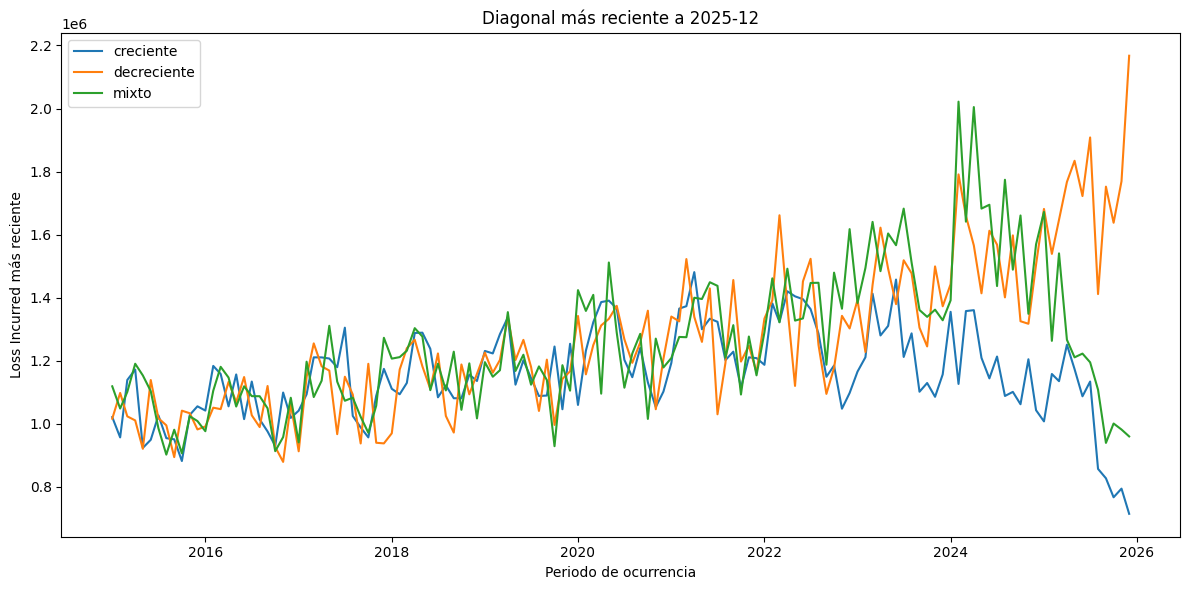

In [80]:
fig, ax = plt.subplots(figsize=(12, 6))

for scenario, diagonal in diagonals.items():

    dates = (
        diagonal["accident_period"]
        .dt.to_timestamp()
    )

    ax.plot(
        dates,
        diagonal["latest_loss_incurred"],
        label=scenario,
    )

ax.set_xlabel("Periodo de ocurrencia")
ax.set_ylabel("Loss Incurred más reciente")
ax.set_title(
    f"Diagonal más reciente a {VALUATION_PERIOD}"
)

ax.legend()

plt.tight_layout()
plt.show()

### Resultado de la diagonal más reciente

A diciembre de 2025, 72 de los 132 periodos de ocurrencia del escenario
creciente han alcanzado su horizonte de 60 meses, mientras que 60 permanecen
inmaduros.

En los escenarios decreciente y mixto, cuyo horizonte es de 48 meses,
84 periodos se encuentran maduros y 48 continúan en desarrollo.

La divergencia observada entre las curvas en los periodos más recientes no
debe interpretarse como una diferencia exclusiva en la tendencia de
ocurrencia. En esa zona, cada escenario se encuentra en una fase distinta
de su patrón de desarrollo.

Por ello, la tendencia y la estacionalidad se estudian a continuación
utilizando las variables correspondientes al proceso de ocurrencia y no la
diagonal del triángulo.

### 6.2 Tendencia y estacionalidad de ocurrencia

La diagonal analizada previamente combina dos dimensiones:

- nivel de pérdida del periodo de ocurrencia;
- edad de desarrollo observada.

Para estudiar exclusivamente el proceso de ocurrencia se utilizan ahora las
variables generadas antes de aplicar el patrón de desarrollo.

La simulación sigue conceptualmente la estructura:

$$
U_i
=
U_0
\times T_i
\times S_i
\times \varepsilon_i,
$$

donde:

- $U_i$ es el Ultimate simulado;
- $T_i$ es el factor de tendencia;
- $S_i$ es el factor estacional;
- $\varepsilon_i$ representa variabilidad aleatoria.

Estas variables pertenecen al periodo de ocurrencia y se repiten en la base
larga para cada edad de desarrollo. Por ello, antes del análisis se construye
una vista con una sola observación por `accident_period`.

In [81]:
from src.analysis import build_occurrence_view

In [82]:
occurrence_views = {
    scenario: build_occurrence_view(df)
    for scenario, df in simulations.items()
}

In [83]:
occurrence_summary = pd.DataFrame(
    [
        {
            "scenario": scenario,
            "periods": len(df),
            "start": df["accident_period"].min(),
            "end": df["accident_period"].max(),
            "ultimate_mean": df["ultimate_loss"].mean(),
            "ultimate_min": df["ultimate_loss"].min(),
            "ultimate_max": df["ultimate_loss"].max(),
        }
        for scenario, df in occurrence_views.items()
    ]
)

occurrence_summary

,scenario,periods,start,end,ultimate_mean,ultimate_min,ultimate_max
0,creciente,132,2015-01,2025-12,1.239533e+06,882135.516211,1.794109e+06
1,decreciente,132,2015-01,2025-12,1.231571e+06,879389.279808,1.709760e+06
2,mixto,132,2015-01,2025-12,1.254085e+06,902439.949221,1.746244e+06


#### 6.2.1 Tendencia introducida en la simulación

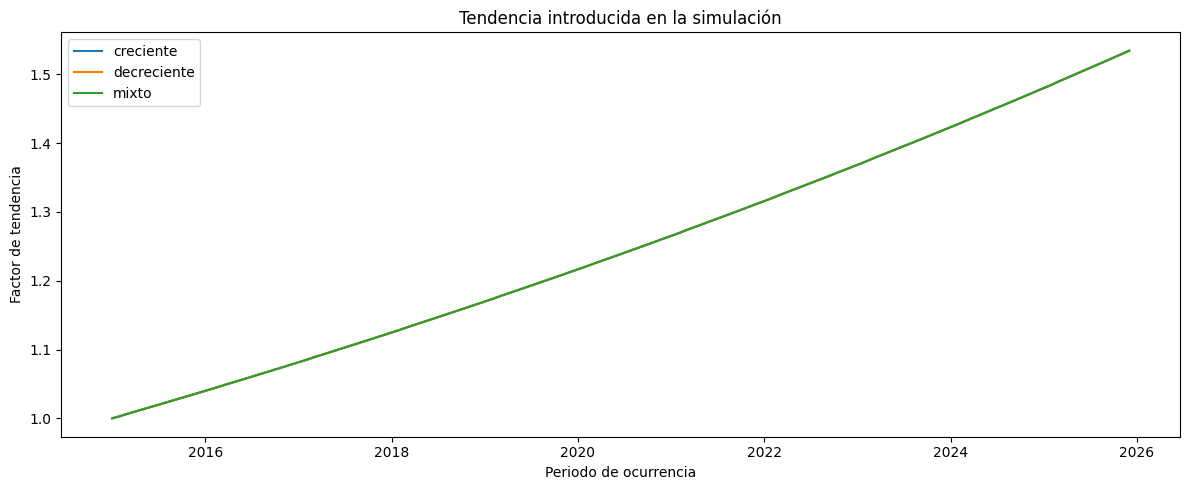

In [84]:
fig, ax = plt.subplots(figsize=(12, 5))

for scenario, df in occurrence_views.items():

    ax.plot(
        df["accident_period"].dt.to_timestamp(),
        df["trend_factor"],
        label=scenario,
    )

ax.set_xlabel("Periodo de ocurrencia")
ax.set_ylabel("Factor de tendencia")
ax.set_title(
    "Tendencia introducida en la simulación"
)

ax.legend()

plt.tight_layout()
plt.show()

#### 6.2.2 Ultimate observado

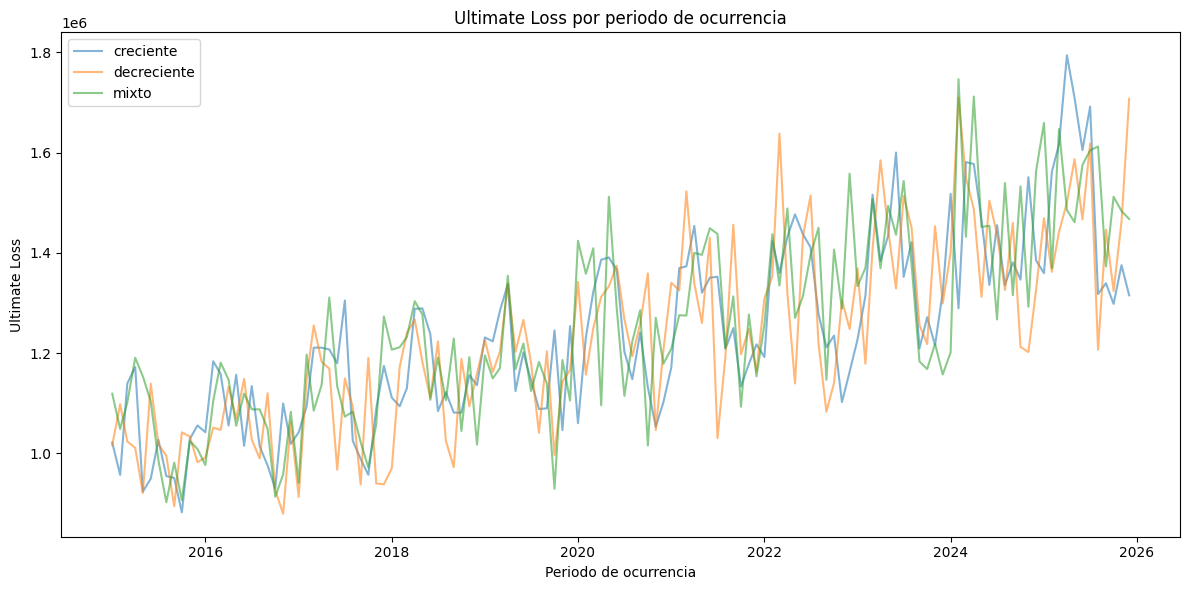

In [85]:
fig, ax = plt.subplots(figsize=(12, 6))

for scenario, df in occurrence_views.items():

    ax.plot(
        df["accident_period"].dt.to_timestamp(),
        df["ultimate_loss"],
        alpha=0.55,
        label=scenario,
    )

ax.set_xlabel("Periodo de ocurrencia")
ax.set_ylabel("Ultimate Loss")
ax.set_title(
    "Ultimate Loss por periodo de ocurrencia"
)

ax.legend()

plt.tight_layout()
plt.show()

#### 6.2.3 Tendencia suavizada

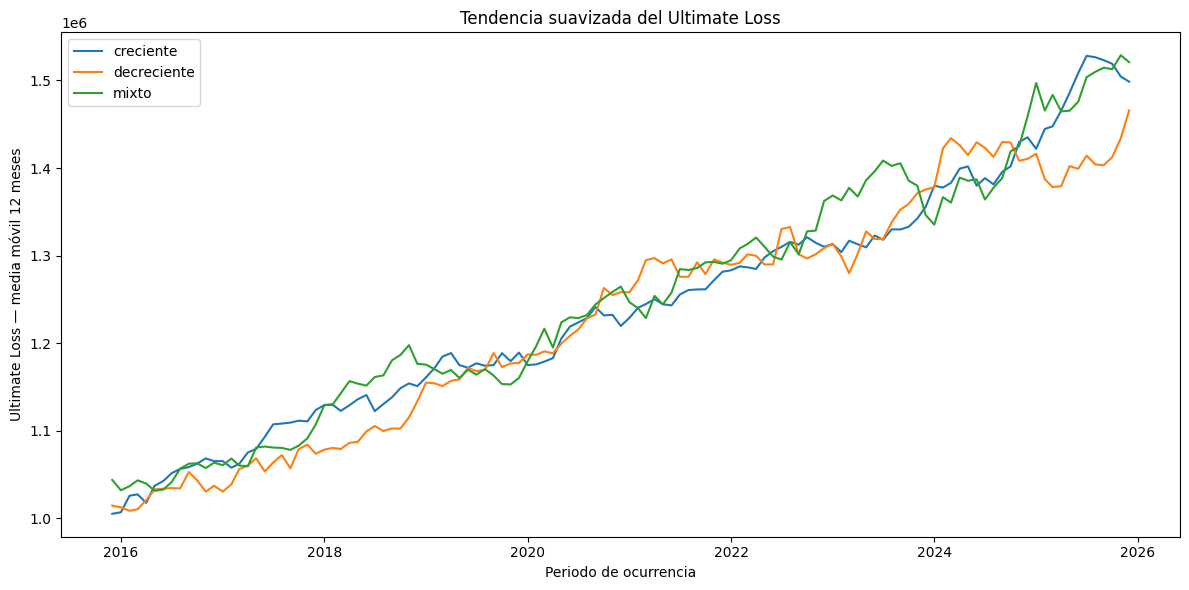

In [86]:
fig, ax = plt.subplots(figsize=(12, 6))

for scenario, df in occurrence_views.items():

    dates = (
        df["accident_period"]
        .dt.to_timestamp()
    )

    rolling_mean = (
        df["ultimate_loss"]
        .rolling(
            window=12,
            min_periods=12,
        )
        .mean()
    )

    ax.plot(
        dates,
        rolling_mean,
        label=scenario,
    )

ax.set_xlabel("Periodo de ocurrencia")
ax.set_ylabel(
    "Ultimate Loss — media móvil 12 meses"
)

ax.set_title(
    "Tendencia suavizada del Ultimate Loss"
)

ax.legend()

plt.tight_layout()
plt.show()

### 6.3 Estacionalidad

In [87]:
seasonality_summary = pd.concat(
    occurrence_views.values(),
    ignore_index=True,
)

seasonality_summary = (
    seasonality_summary
    .groupby("month")
    .agg(
        mean_seasonality_factor=(
            "seasonality_factor",
            "mean",
        ),
    )
    .reset_index()
)

seasonality_summary

,month,mean_seasonality_factor
0,1,1.000000
1,2,1.040000
2,3,1.069282
3,4,1.080000
4,5,1.069282
5,6,1.040000
6,7,1.000000
7,8,0.960000
8,9,0.930718
9,10,0.920000


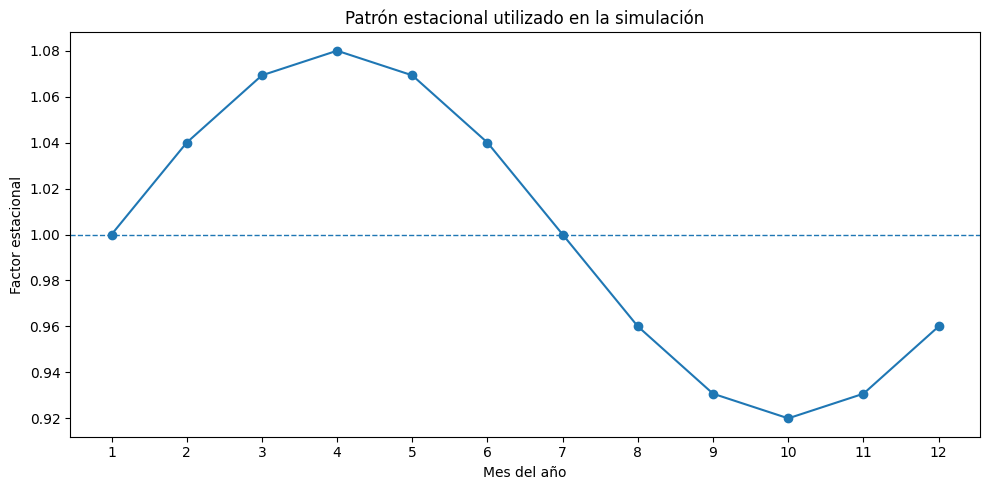

In [88]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    seasonality_summary["month"],
    seasonality_summary[
        "mean_seasonality_factor"
    ],
    marker="o",
)

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1,
)

ax.set_xticks(range(1, 13))

ax.set_xlabel("Mes del año")
ax.set_ylabel("Factor estacional")
ax.set_title(
    "Patrón estacional utilizado en la simulación"
)

plt.tight_layout()
plt.show()

### Estacionalidad en el Ultimate

Tenemos que normalizar la tendencia.
Como conocemos el factor generador, podemos construir:

$$
U_i^{adj}
=
\frac{U_i}{T_i}.
$$

In [89]:
for scenario, df in occurrence_views.items():

    df["ultimate_detrended"] = (
        df["ultimate_loss"]
        / df["trend_factor"]
    )

In [90]:
seasonality_observed = pd.concat(
    [
        df[
            [
                "scenario",
                "month",
                "ultimate_detrended",
            ]
        ]
        for df in occurrence_views.values()
    ],
    ignore_index=True,
)

In [91]:
seasonality_observed_summary = (
    seasonality_observed
    .groupby(
        ["scenario", "month"],
        as_index=False,
    )
    .agg(
        mean_ultimate_detrended=(
            "ultimate_detrended",
            "mean",
        )
    )
)

In [92]:
seasonality_observed_summary[
    "relative_level"
] = (
    seasonality_observed_summary[
        "mean_ultimate_detrended"
    ]
    / seasonality_observed_summary
      .groupby("scenario")[
          "mean_ultimate_detrended"
      ]
      .transform("mean")
)

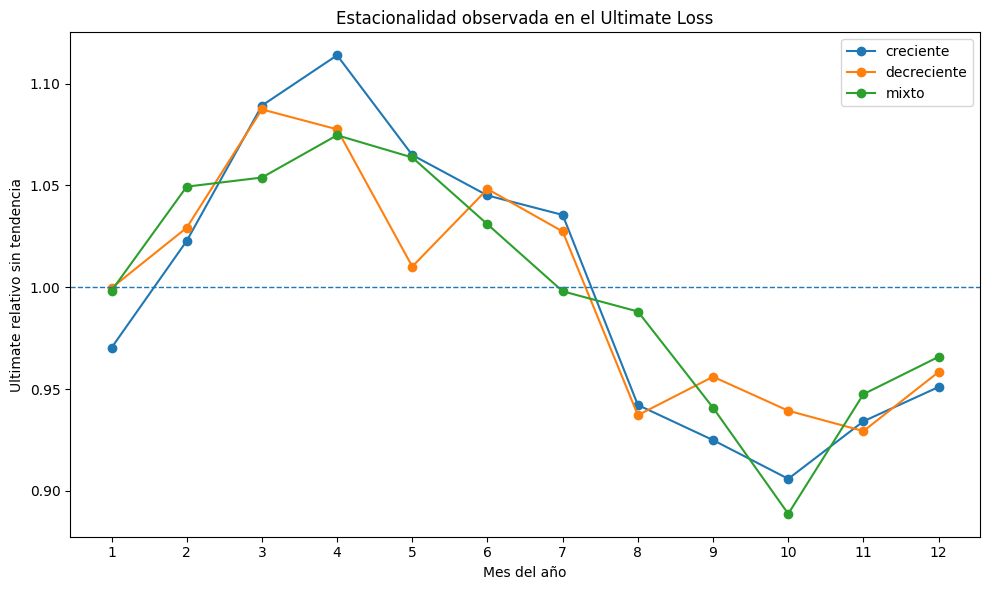

In [93]:
fig, ax = plt.subplots(figsize=(10, 6))

for scenario, df in (
    seasonality_observed_summary
    .groupby("scenario")
):

    ax.plot(
        df["month"],
        df["relative_level"],
        marker="o",
        label=scenario,
    )

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1,
)

ax.set_xticks(range(1, 13))

ax.set_xlabel("Mes del año")
ax.set_ylabel(
    "Ultimate relativo sin tendencia"
)

ax.set_title(
    "Estacionalidad observada en el Ultimate Loss"
)

ax.legend()

plt.tight_layout()
plt.show()

### Interpretación de tendencia y estacionalidad

El análisis confirma que la dinámica temporal de ocurrencia es independiente
del patrón de desarrollo definido posteriormente para cada escenario.

El `trend_factor` presenta la evolución gradual especificada durante la
simulación. Al observar directamente el Ultimate, dicha tendencia aparece
combinada con estacionalidad y variabilidad aleatoria, por lo que la serie
mensual resulta considerablemente más irregular.

La media móvil de 12 meses permite visualizar con mayor claridad el
crecimiento subyacente y, al cubrir un ciclo anual completo, reduce parte
de la oscilación estacional.

Para analizar la estacionalidad se elimina primero el efecto conocido de
tendencia:

$$
U_i^{adj}
=
\frac{U_i}{T_i}.
$$

Posteriormente se comparan los niveles medios por mes del año. El patrón
resultante permite comprobar que la estacionalidad incorporada durante la
simulación permanece observable incluso después de añadir variación aleatoria.

La separación entre ocurrencia y desarrollo es fundamental: los tres
escenarios pueden compartir una dinámica de Ultimate similar y, aun así,
producir diagonales y triángulos muy distintos debido exclusivamente a sus
diferentes patrones de desarrollo.

### 6.4 Visualización de los triángulos

Además de inspeccionar numéricamente los triángulos, se utilizan mapas de
calor para representar simultáneamente:

- los periodos de ocurrencia;
- las edades de desarrollo;
- la magnitud del Loss Incurred;
- la frontera entre información observable y desarrollos futuros.

Las celdas vacías corresponden a combinaciones que aún no son observables
a la fecha de valuación 2025-12.

En el triángulo acumulado, la intensidad representa el nivel alcanzado por
el Loss Incurred.

En el incremental, los valores representan los cambios ocurridos entre
edades consecutivas de desarrollo, por lo que pueden ser positivos o
negativos.

### Import

In [94]:
from src.visualization import (
    plot_triangle_heatmap,
)

### Triángulos acumulados

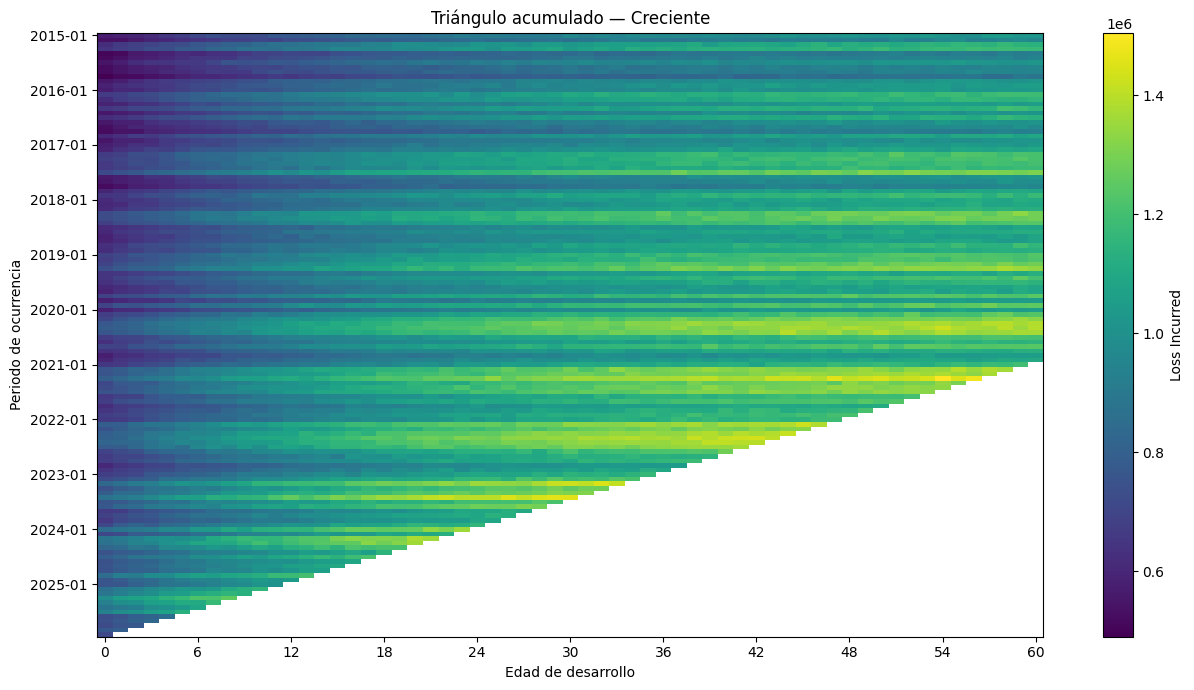

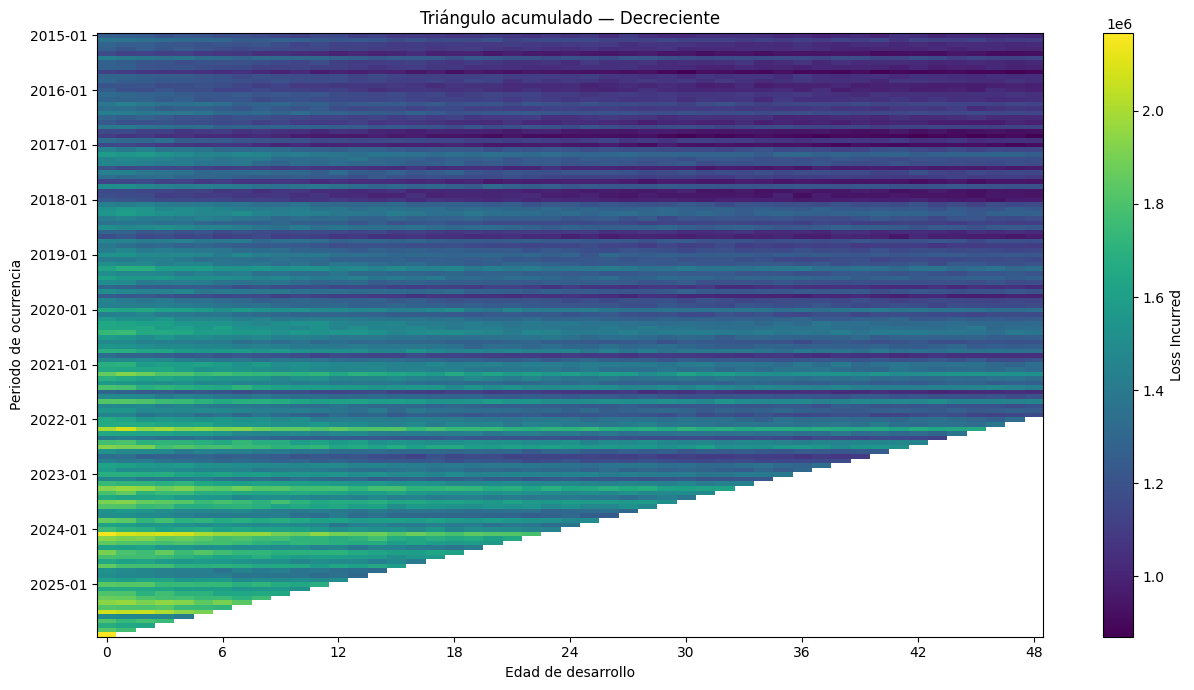

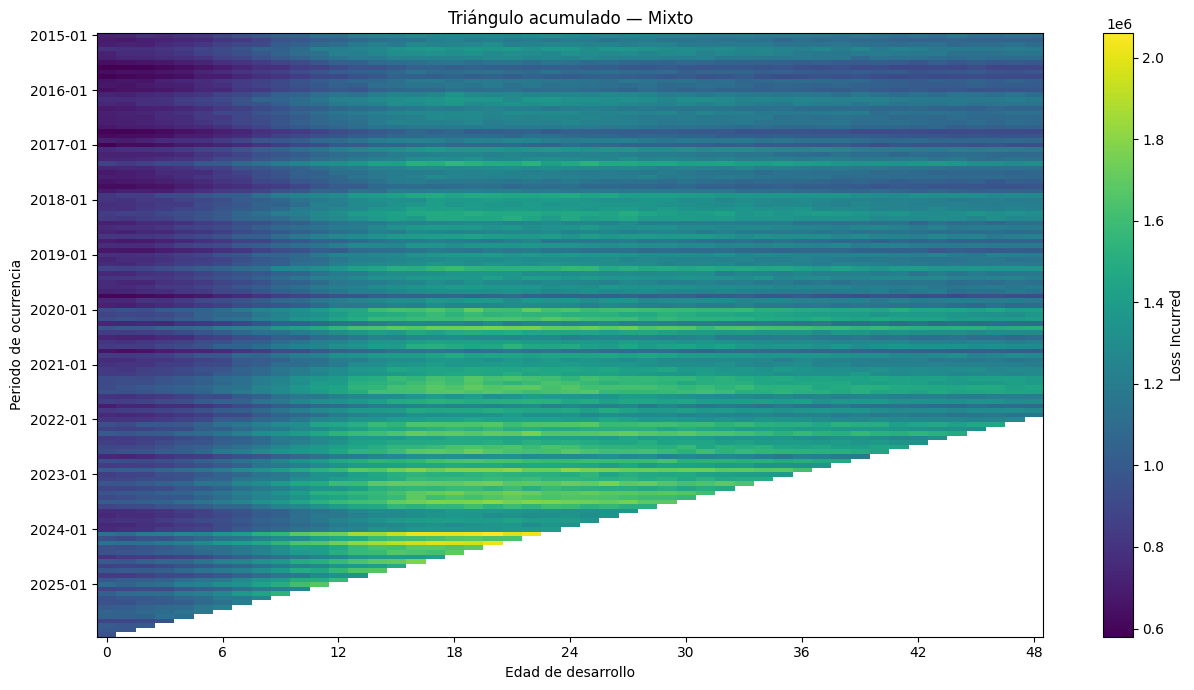

In [95]:
for scenario, pair in triangles.items():

    plot_triangle_heatmap(
        triangle=pair["cumulative"],
        title=(
            f"Triángulo acumulado — "
            f"{scenario.capitalize()}"
        ),
    )

    plt.show()

### Triángulos incrementales

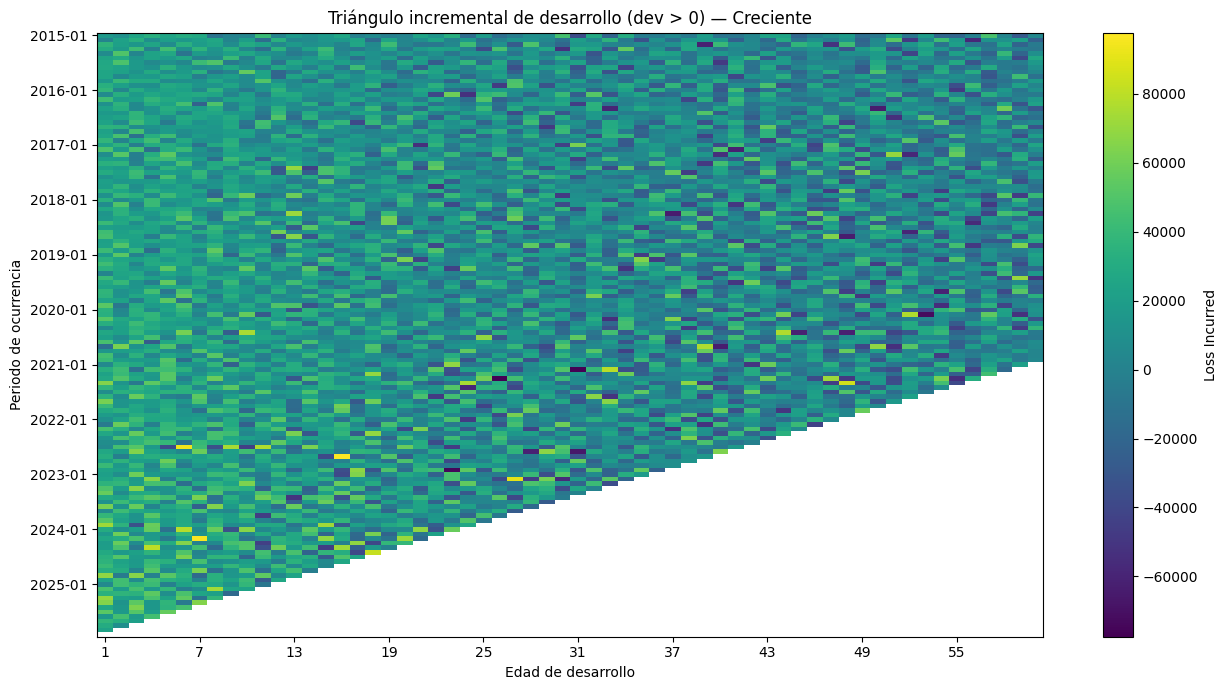

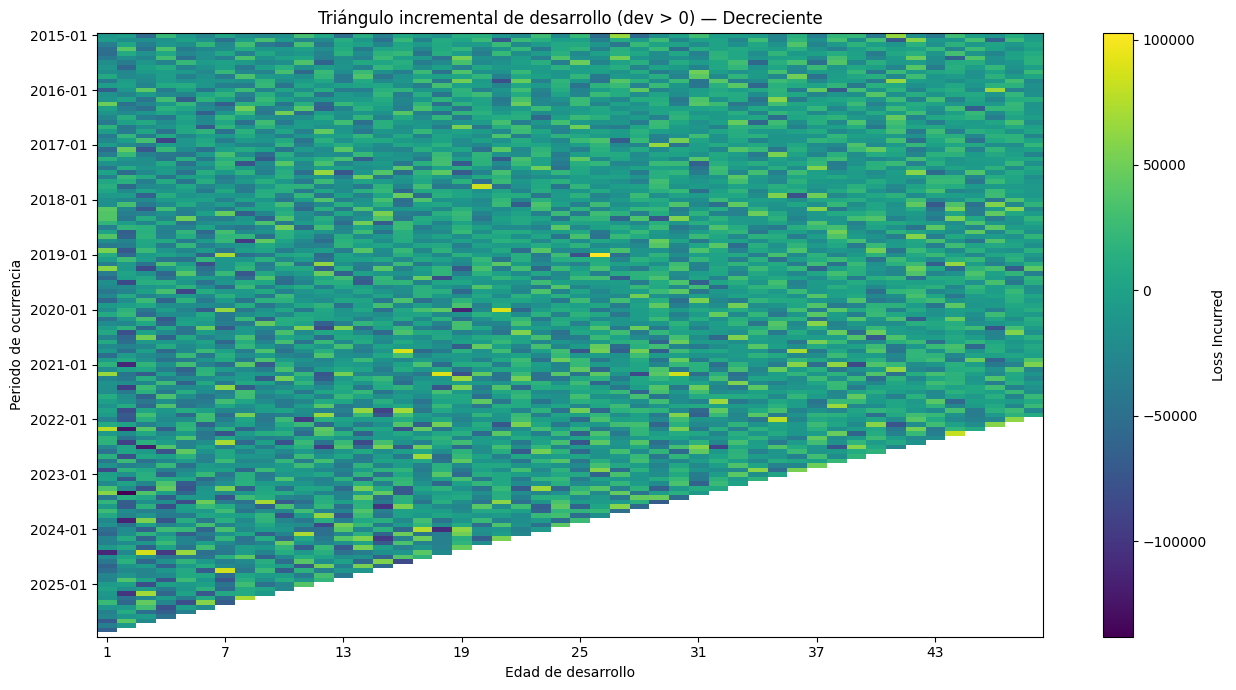

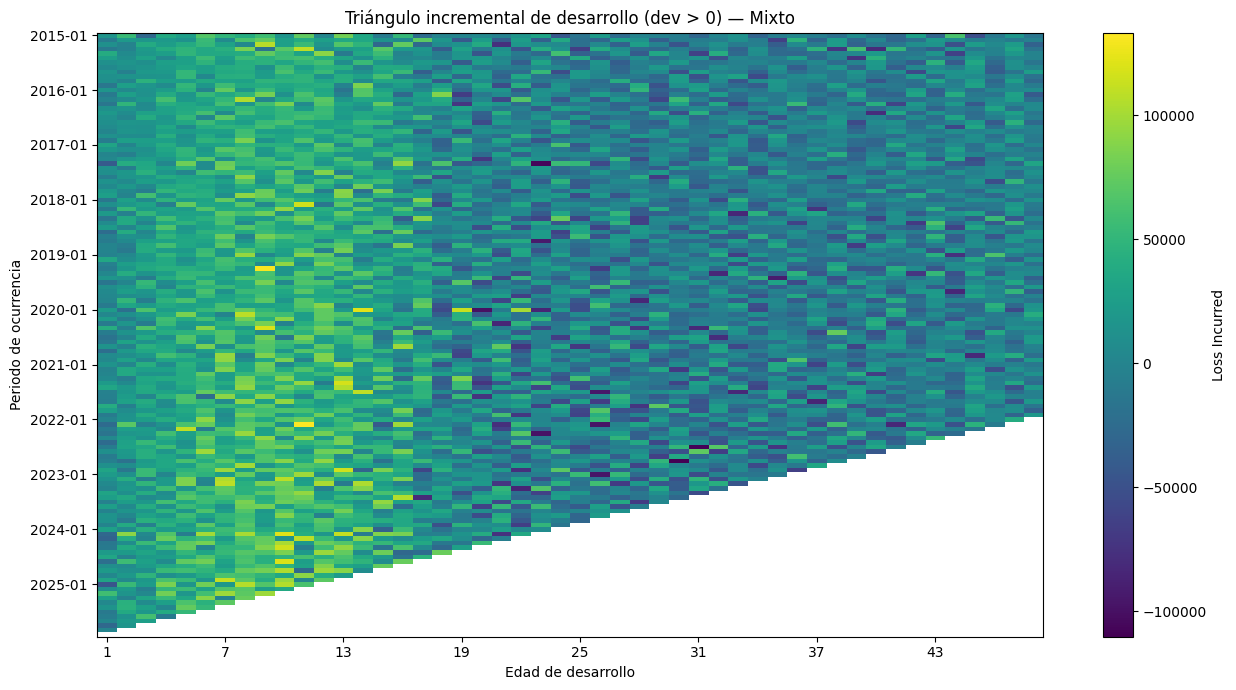

In [103]:
for scenario, pair in triangles.items():

    incremental_development = (
        pair["incremental"]
        .iloc[:, 1:]
    )

    plot_triangle_heatmap(
        triangle=incremental_development,
        title=(
            "Triángulo incremental de desarrollo "
            f"(dev > 0) — {scenario.capitalize()}"
        ),
    )

    plt.show()

### Interpretación visual de los triángulos

Los mapas de calor confirman la estructura triangular generada por el corte
a diciembre de 2025.

En los triángulos acumulados, los periodos antiguos presentan desarrollos
completos hasta `dev_M`, mientras que los periodos recientes contienen
progresivamente menos edades observadas.

La lectura de los triángulos incrementales refleja además la naturaleza de
cada escenario:

- en el escenario creciente predominan aumentos del Loss Incurred;
- en el decreciente aparecen con mayor frecuencia revisiones negativas;
- en el mixto se combinan incrementos tempranos con ajustes posteriores.

Las diferencias corresponden al patrón de desarrollo y no a diferencias
estructurales en el proceso de ocurrencia, que fue generado bajo una
dinámica temporal comparable para los tres escenarios.

### 6.5 Presentación de factores edad a edad

In [97]:
from src.visualization import (
    plot_triangle_heatmap,
    plot_development_factors,
)

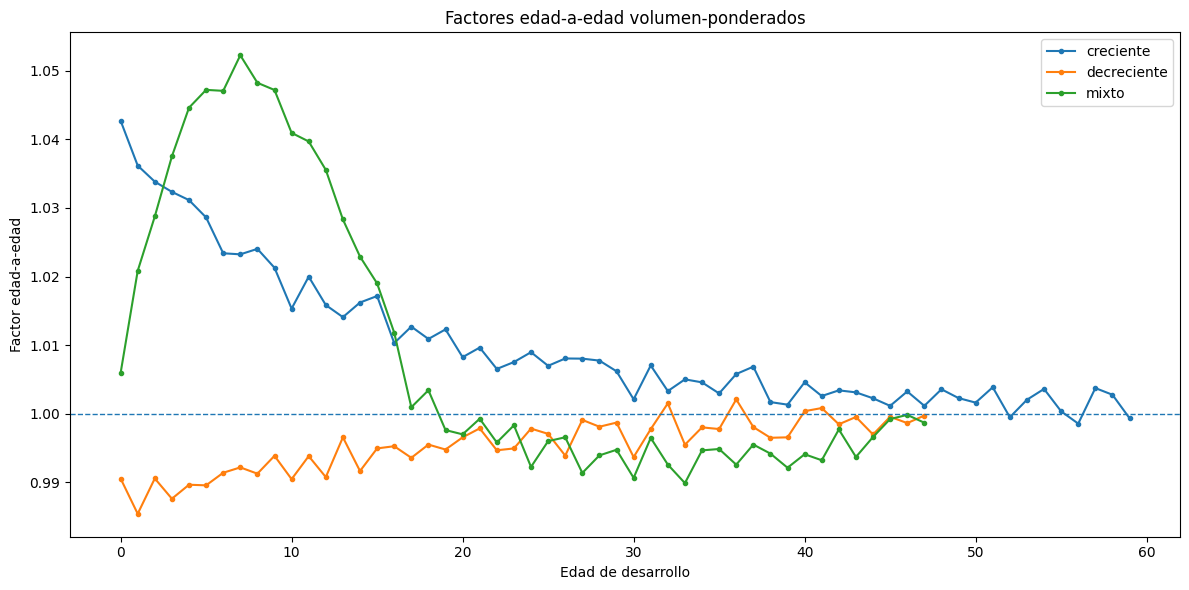

In [98]:
plot_development_factors(
    development_factors
)

plt.show()

### 6.6 Tabla comparativa de cierre

In [99]:
scenario_comparison = (
    factor_summary[
        [
            "n_factors",
            "mean_factor",
            "factors_above_1",
            "factors_below_1",
            "pct_above_1",
            "pct_below_1",
        ]
    ]
    .join(
        diagonal_summary
        .set_index("scenario")[
            [
                "mature_periods",
                "immature_periods",
                "mature_pct",
            ]
        ]
    )
)

scenario_comparison

,n_factors,mean_factor,factors_above_1,factors_below_1,pct_above_1,pct_below_1,mature_periods,immature_periods,mature_pct
scenario,,,,,,,,,
creciente,60,1.010050,57,3,0.950000,0.050000,72,60,0.545455
decreciente,48,0.995416,4,44,0.083333,0.916667,84,48,0.636364
mixto,48,1.009204,19,29,0.395833,0.604167,84,48,0.636364


In [100]:
EXPECTED_PATTERN = {
    "creciente": (
        "Aumento progresivo y "
        "convergencia a 1"
    ),
    "decreciente": (
        "Ajuste decreciente y "
        "convergencia a 1"
    ),
    "mixto": (
        "Aumento temprano y "
        "reducción posterior"
    ),
}

scenario_comparison[
    "expected_pattern"
] = (
    scenario_comparison.index.map(
        EXPECTED_PATTERN
    )
)

In [101]:
scenario_comparison.insert(
    0,
    "dev_M",
    pd.Series(EXPECTED_DEV_M),
)

scenario_comparison

,dev_M,n_factors,mean_factor,factors_above_1,factors_below_1,pct_above_1,pct_below_1,mature_periods,immature_periods,mature_pct,expected_pattern
scenario,,,,,,,,,,,
creciente,60,60,1.010050,57,3,0.950000,0.050000,72,60,0.545455,Aumento progresivo y convergencia a 1
decreciente,48,48,0.995416,4,44,0.083333,0.916667,84,48,0.636364,Ajuste decreciente y convergencia a 1
mixto,48,48,1.009204,19,29,0.395833,0.604167,84,48,0.636364,Aumento temprano y reducción posterior


## Conclusión de la exploración

La exploración de los tres escenarios confirma que las bases presentan una
estructura temporal común en el proceso de ocurrencia, pero comportamientos
claramente distintos durante el desarrollo.

La diagonal más reciente evidencia que el valor observado a una fecha de
valuación depende tanto del nivel de pérdida como de la edad alcanzada.

El análisis separado del proceso de ocurrencia permite identificar la
tendencia, estacionalidad y variación aleatoria incorporadas durante la
simulación sin confundir estos efectos con el desarrollo.

Por su parte, los triángulos acumulados e incrementales reproducen la
estructura esperada a diciembre de 2025 y los factores edad-a-edad
permiten distinguir claramente los tres mecanismos de desarrollo:

- crecimiento progresivo;
- ajuste decreciente;
- crecimiento temprano seguido de reducción.

Con ello, las bases quedan validadas y caracterizadas antes de introducir
cualquier metodología de estimación o selección de modelos.

## 7. Interpretación actuarial de los escenarios

Una vez verificadas la estructura de las bases, los triángulos, las
diagonales y los factores edad-a-edad, se interpreta el significado
actuarial de cada patrón de desarrollo.

El objetivo de esta sección no es introducir nuevos criterios de
validación, sino integrar la evidencia obtenida anteriormente.

En particular, se consideran conjuntamente:

- la evolución del Loss Incurred por edad de desarrollo;
- los factores edad-a-edad;
- los movimientos incrementales;
- la convergencia hacia `dev_M`;
- la posición de los periodos maduros e inmaduros a la valuación
  de diciembre de 2025.

### 7.1 Escenario creciente

El escenario creciente representa una trayectoria en la que el Loss
Incurred inicialmente reconoce solo una parte del Ultimate y aumenta
progresivamente conforme avanza el desarrollo.

Los factores edad-a-edad confirman este comportamiento: 57 de los 60
factores agregados, equivalentes al 95 %, son superiores a 1.

En términos generales:

$$
LI_{i,j+1} > LI_{i,j}.
$$

Los mayores factores se concentran en edades tempranas, mientras que su
magnitud disminuye progresivamente conforme aumenta el desarrollo:

$$
f_j \rightarrow 1.
$$

Esta convergencia indica que cada nueva edad aporta modificaciones cada
vez menores al Loss Incurred.

A la edad `dev_M = 60` se cumple por construcción:

$$
LI_{i,60}=U_i,
$$

por lo que el periodo se considera completamente desarrollado.

Desde una perspectiva actuarial, un patrón de este tipo podría representar
situaciones en las que la estimación inicial de la pérdida resulta
insuficiente y posteriormente se incorporan nuevos pagos, fortalecimientos
de reserva o información adicional que incrementa la estimación total del
siniestro.

Los incrementales individuales no son necesariamente positivos en todas
las observaciones debido a la variabilidad incorporada en la simulación.
Sin embargo, el comportamiento agregado conserva claramente la dirección
creciente definida para el escenario.

### 7.2 Escenario decreciente

El escenario decreciente representa el comportamiento opuesto. El Loss
Incurred comienza en un nivel relativamente elevado respecto de su Ultimate
y posteriormente se revisa hacia abajo conforme se obtiene nueva
información.

En este escenario, 44 de los 48 factores edad-a-edad agregados
(91.7 %) son inferiores a 1:

$$
LI_{i,j+1} < LI_{i,j}.
$$

Al igual que en el escenario creciente, las modificaciones son mayores en
las primeras edades y disminuyen gradualmente conforme se aproxima la
madurez:

$$
f_j \rightarrow 1.
$$

En `dev_M = 48` el Loss Incurred converge finalmente al Ultimate simulado.

Actuarialmente, un patrón decreciente puede asociarse con estimaciones
iniciales conservadoras que posteriormente se reducen por liberación de
reservas, cierres favorables o nueva información que disminuye la pérdida
esperada.

En consecuencia, la presencia de incrementos negativos en el triángulo
incremental no constituye una anomalía. En este escenario representa
precisamente revisiones descendentes del valor acumulado.

### 7.3 Escenario mixto

El escenario mixto combina ambos mecanismos de desarrollo.

Durante las edades tempranas, el Loss Incurred aumenta:

$$
f_j > 1,
$$

mientras que posteriormente se alcanza una zona de transición y el
desarrollo cambia de dirección:

$$
f_j < 1.
$$

La validación por regiones confirma este comportamiento: en la zona
temprana evaluada todos los factores agregados son superiores a 1,
mientras que en la zona tardía todos son inferiores a 1.

Por tanto, el desarrollo puede representarse conceptualmente como:

$$
\text{aumento inicial}
\quad\longrightarrow\quad
\text{máximo}
\quad\longrightarrow\quad
\text{ajuste descendente}
\quad\longrightarrow\quad
\text{Ultimate}.
$$

Este escenario es especialmente relevante porque demuestra que la
trayectoria del Loss Incurred no tiene por qué ser monótona.

Una posible interpretación actuarial sería un proceso en el que la pérdida
se fortalece durante las primeras edades a medida que aparece nueva
información, pero posteriormente parte de esa estimación se libera o
corrige conforme los siniestros se estabilizan.

Finalmente, en `dev_M = 48` el Loss Incurred converge al Ultimate, al igual
que en los otros escenarios.

### 7.4 Comparación de los mecanismos de desarrollo

Los tres escenarios comparten el mismo tipo de estructura de ocurrencia:
tendencia, estacionalidad y variación aleatoria.

La diferencia fundamental entre ellos se introduce posteriormente mediante
el mecanismo de desarrollo del Loss Incurred.

Esto permite aislar el efecto del patrón de desarrollo y estudiar cómo
diferentes trayectorias pueden producir triángulos y diagonales distintos
incluso cuando el proceso subyacente de ocurrencia es comparable.

In [102]:
display(scenario_comparison)

,dev_M,n_factors,mean_factor,factors_above_1,factors_below_1,pct_above_1,pct_below_1,mature_periods,immature_periods,mature_pct,expected_pattern
scenario,,,,,,,,,,,
creciente,60,60,1.010050,57,3,0.950000,0.050000,72,60,0.545455,Aumento progresivo y convergencia a 1
decreciente,48,48,0.995416,4,44,0.083333,0.916667,84,48,0.636364,Ajuste decreciente y convergencia a 1
mixto,48,48,1.009204,19,29,0.395833,0.604167,84,48,0.636364,Aumento temprano y reducción posterior


### 7.5 Relación entre ocurrencia, desarrollo y diagonal

Los resultados muestran que el nivel observado de Loss Incurred a una
fecha de valuación depende de dos procesos diferentes:

$$
LI_{i,j}
=
U_i
\times
D_j,
$$

de forma conceptual, donde:

- $U_i$ representa el nivel correspondiente al periodo de ocurrencia;
- $D_j$ representa el estado de desarrollo alcanzado.

Por esta razón, dos periodos con Ultimate similares pueden mostrar valores
muy distintos en una diagonal si se encuentran en edades diferentes.

Del mismo modo, los tres escenarios pueden compartir una tendencia de
ocurrencia comparable y generar diagonales claramente distintas debido
únicamente a sus patrones de desarrollo.

Esto explica por qué una diagonal no debe utilizarse por sí sola para
inferir tendencia, estacionalidad o nivel Ultimate sin considerar
simultáneamente la madurez de cada periodo.

### 7.6 Estado de madurez a diciembre de 2025

La elección de `dev_M` también determina cuántos periodos pueden
considerarse completamente desarrollados a la fecha de valuación.

En el escenario creciente, con `dev_M = 60`, se encuentran maduros
72 de los 132 periodos de ocurrencia:

$$
\frac{72}{132}=54.5\%.
$$

Los 60 periodos restantes todavía poseen desarrollo pendiente.

En los escenarios decreciente y mixto, con `dev_M = 48`, se encuentran
maduros 84 periodos:

$$
\frac{84}{132}=63.6\%.
$$

y permanecen inmaduros los 48 restantes.

Por tanto, un horizonte de desarrollo mayor no solo modifica la trayectoria
del Loss Incurred, sino también la cantidad de historia completamente
desarrollada disponible a una misma fecha de valuación.

### 7.7 Implicaciones para la modelación posterior

Los tres escenarios plantean problemas de estimación diferentes.

En el escenario creciente, un método debe reconocer que los valores
observados en edades jóvenes se encuentran por debajo del Ultimate y que
queda desarrollo positivo pendiente.

En el escenario decreciente ocurre lo contrario: las observaciones
tempranas pueden encontrarse por encima del Ultimate y el desarrollo
esperado implica ajustes negativos.

El escenario mixto resulta más complejo porque la dirección del desarrollo
depende de la edad. Un método que imponga implícitamente una trayectoria
monótona podría representar adecuadamente una parte del desarrollo y
fallar en otra.

Por esta razón, la comparación posterior de metodologías deberá considerar
no solamente el error global de predicción, sino también su comportamiento
en distintas edades de desarrollo y diferentes fechas de valuación.

## 8. Conclusiones

La fase de validación y exploración confirma que los tres escenarios
simulados cumplen las propiedades establecidas en el diseño experimental.

Se verificó que:

1. las bases poseen estructura consistente, claves únicas, importes
   positivos y periodos de desarrollo completos;

2. los horizontes `dev_M` se respetan y el Loss Incurred converge
   exactamente al Ultimate en la madurez;

3. los factores edad-a-edad reproducen los patrones definidos:
   crecimiento, reducción y comportamiento mixto;

4. los triángulos acumulados e incrementales respetan el corte calendario
   de diciembre de 2025 y pueden transformarse entre sí sin pérdida de
   información;

5. la diagonal más reciente distingue correctamente periodos maduros e
   inmaduros;

6. la tendencia y estacionalidad del proceso de ocurrencia pueden separarse
   conceptualmente del efecto del desarrollo;

7. las diferencias observadas entre los escenarios provienen
   principalmente del mecanismo de desarrollo diseñado.

Con estas comprobaciones, las bases quedan preparadas para la siguiente
etapa del experimento: la construcción de valuaciones históricas, el
backtesting y la comparación de metodologías de estimación del desarrollo
futuro.